# 📊 Notebook 05 — Evaluation & Comparison
**Chicago Crime ML Pipeline**

Deep evaluation of all trained models on the **held-out test set** — the data no model has ever seen.

| Task | Evaluation Metrics |
|---|---|
| 1 — Arrest Prediction | Accuracy, F1, ROC-AUC, Confusion Matrix, Precision-Recall Curve |
| 2 — Crime Type Prediction | Accuracy, F1 per class, Confusion Matrix, Classification Report |
| 3 — Crime Count (Regression) | RMSE, MAE, R², Residual Plot, Actual vs Predicted |

> **Next notebook:** `06_feature_importance_report.ipynb`

---
## 1. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, json, joblib

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR  = 'ml_data'
MODEL_DIR = 'ml_models'
RANDOM_STATE = 42

print('Setup complete ✅')

Setup complete ✅


---
## 2. Load Test Data & Models

In [2]:
# ⚡ Config guard — ensures variables are defined even if cells run out of order
DATA_DIR     = globals().get('DATA_DIR',  'ml_data')
MODEL_DIR    = globals().get('MODEL_DIR', 'ml_models')
RANDOM_STATE = globals().get('RANDOM_STATE', 42)

def load_task(task_name):
    data = np.load(f'{DATA_DIR}/{task_name}_preprocessed.npz', allow_pickle=True)
    with open(f'{DATA_DIR}/{task_name}_meta.json') as f:
        meta = json.load(f)
    return data['X_test'], data['y_test'], meta

X_te1, y_te1, meta1 = load_task('task1')
X_te2, y_te2, meta2 = load_task('task2')
X_te3, y_te3, meta3 = load_task('task3')

# Load all models
model_files = {
    'task1': {
        'Logistic Regression' : joblib.load(f'{MODEL_DIR}/task1_logistic_regression.pkl'),
        'Random Forest'       : joblib.load(f'{MODEL_DIR}/task1_random_forest.pkl'),
        'Gradient Boosting'   : joblib.load(f'{MODEL_DIR}/task1_gradient_boosting.pkl'),
    },
    'task2': {
        'Logistic Regression' : joblib.load(f'{MODEL_DIR}/task2_logistic_regression.pkl'),
        'Random Forest'       : joblib.load(f'{MODEL_DIR}/task2_random_forest.pkl'),
        'Gradient Boosting'   : joblib.load(f'{MODEL_DIR}/task2_gradient_boosting.pkl'),
    },
    'task3': {
        'Ridge Regression'  : joblib.load(f'{MODEL_DIR}/task3_ridge_regression.pkl'),
        'Random Forest'     : joblib.load(f'{MODEL_DIR}/task3_random_forest.pkl'),
        'Gradient Boosting' : joblib.load(f'{MODEL_DIR}/task3_gradient_boosting.pkl'),
    }
}

# Load label map for task 2
with open(f'{DATA_DIR}/task2_label_map.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in sorted(label_map.keys(), key=int)]

# Load training summary
with open(f'{MODEL_DIR}/training_summary.json') as f:
    train_summary = json.load(f)

print('All models and test data loaded ✅')
for task, models in model_files.items():
    print(f'  {task}: {list(models.keys())}')

All models and test data loaded ✅
  task1: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
  task2: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
  task3: ['Ridge Regression', 'Random Forest', 'Gradient Boosting']


---
## 3. Task 1 — Arrest Prediction: Full Test Evaluation

In [3]:
print('🔵 TASK 1 — Arrest Prediction — Test Set Results')
print('=' * 65)

t1_results = {}
for name, model in model_files['task1'].items():
    y_pred = model.predict(X_te1)
    y_prob = model.predict_proba(X_te1)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_te1, y_pred)
    f1  = f1_score(y_te1, y_pred, average='weighted')
    f1_macro = f1_score(y_te1, y_pred, average='macro')
    auc = roc_auc_score(y_te1, y_prob) if y_prob is not None else None
    ap  = average_precision_score(y_te1, y_prob) if y_prob is not None else None

    t1_results[name] = dict(acc=acc, f1=f1, f1_macro=f1_macro, auc=auc, ap=ap,
                             y_pred=y_pred, y_prob=y_prob)

    auc_str = f'{auc:.4f}' if auc else 'N/A'
    print(f'  {name:<25} Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc_str}')

best_t1 = max(t1_results, key=lambda n: t1_results[n]['auc'] or 0)
print(f'\n  🏆 Best on test: {best_t1}')

🔵 TASK 1 — Arrest Prediction — Test Set Results
  Logistic Regression       Acc: 0.7681  F1: 0.7649  AUC: 0.8519
  Random Forest             Acc: 0.7843  F1: 0.7775  AUC: 0.8790
  Gradient Boosting         Acc: 0.7957  F1: 0.7918  AUC: 0.8852

  🏆 Best on test: Gradient Boosting


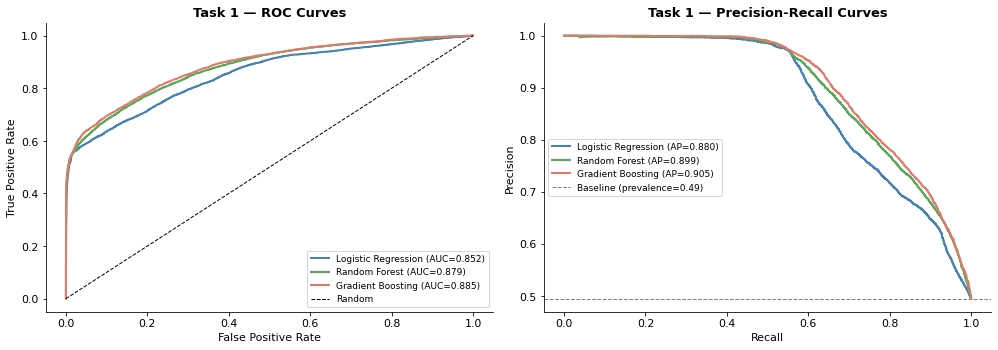

In [4]:
# ── ROC Curves — all Task 1 models ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', '#5ba85b', '#e07b6a']

for (name, res), color in zip(t1_results.items(), colors):
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_te1, res['y_prob'])
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
                     linewidth=2, color=color)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Task 1 — ROC Curves', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9)

# ── Precision-Recall Curves ───────────────────────────────────
for (name, res), color in zip(t1_results.items(), colors):
    if res['y_prob'] is not None:
        prec, rec, _ = precision_recall_curve(y_te1, res['y_prob'])
        axes[1].plot(rec, prec, label=f"{name} (AP={res['ap']:.3f})",
                     linewidth=2, color=color)

baseline = y_te1.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline (prevalence={baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Task 1 — Precision-Recall Curves', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_task1_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

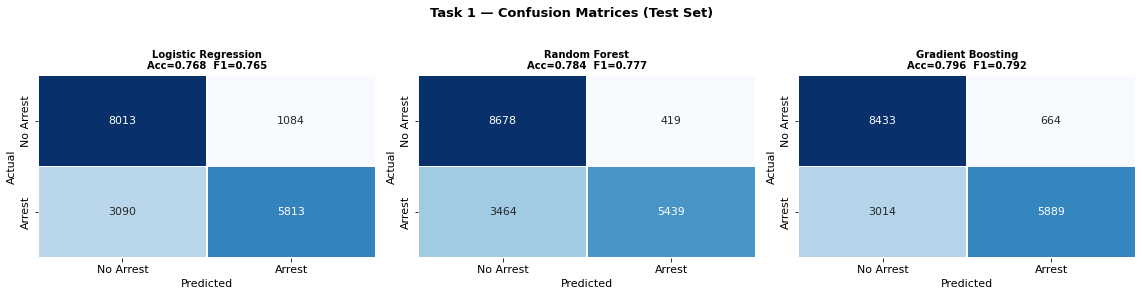

In [5]:
# ── Confusion matrices — all Task 1 models ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, t1_results.items()):
    cm = confusion_matrix(y_te1, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Arrest','Arrest'],
                yticklabels=['No Arrest','Arrest'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f}  F1={res["f1"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Task 1 — Confusion Matrices (Test Set)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_task1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Full classification report — best Task 1 model ────────────
print(f'\n  📋 Classification Report — {best_t1} (best on test)')
print(classification_report(
    y_te1, t1_results[best_t1]['y_pred'],
    target_names=['No Arrest', 'Arrest']
))


  📋 Classification Report — Gradient Boosting (best on test)
              precision    recall  f1-score   support

   No Arrest       0.74      0.93      0.82      9097
      Arrest       0.90      0.66      0.76      8903

    accuracy                           0.80     18000
   macro avg       0.82      0.79      0.79     18000
weighted avg       0.82      0.80      0.79     18000



---
## 4. Task 2 — Crime Type: Full Test Evaluation

In [7]:
print('🟢 TASK 2 — Crime Type Prediction — Test Set Results')
print('=' * 65)

t2_results = {}
for name, model in model_files['task2'].items():
    y_pred = model.predict(X_te2)
    acc      = accuracy_score(y_te2, y_pred)
    f1_w     = f1_score(y_te2, y_pred, average='weighted')
    f1_macro = f1_score(y_te2, y_pred, average='macro')
    f1_per_class = f1_score(y_te2, y_pred, average=None)

    t2_results[name] = dict(acc=acc, f1_w=f1_w, f1_macro=f1_macro,
                             f1_per_class=f1_per_class, y_pred=y_pred)
    print(f'  {name:<25} Acc: {acc:.4f}  F1-weighted: {f1_w:.4f}  F1-macro: {f1_macro:.4f}')

best_t2 = max(t2_results, key=lambda n: t2_results[n]['f1_w'])
print(f'\n  🏆 Best on test: {best_t2}')

🟢 TASK 2 — Crime Type Prediction — Test Set Results
  Logistic Regression       Acc: 0.2748  F1-weighted: 0.2189  F1-macro: 0.1842
  Random Forest             Acc: 0.3893  F1-weighted: 0.3652  F1-macro: 0.2792
  Gradient Boosting         Acc: 0.4614  F1-weighted: 0.4217  F1-macro: 0.3165

  🏆 Best on test: Gradient Boosting


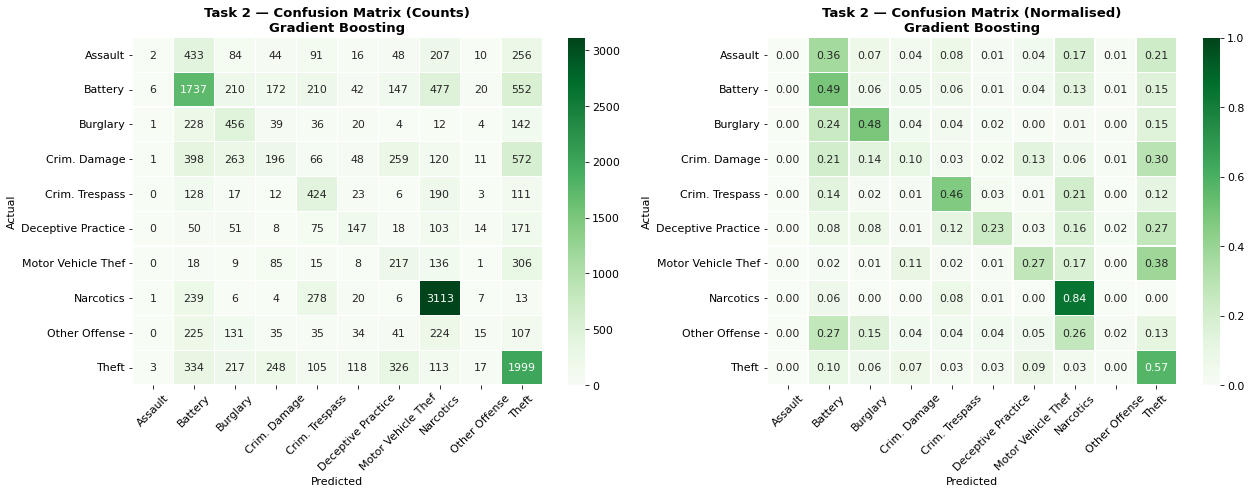

In [8]:
# ── Confusion matrix — best Task 2 model ─────────────────────
cm2 = confusion_matrix(y_te2, t2_results[best_t2]['y_pred'])
cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)

short_names = [n.replace('CRIMINAL ', 'CRIM. ').title()[:18] for n in class_names]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.3, cbar=True)
axes[0].set_title(f'Task 2 — Confusion Matrix (Counts)\n{best_t2}',
                  fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm2_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.3, cbar=True, vmin=0, vmax=1)
axes[1].set_title(f'Task 2 — Confusion Matrix (Normalised)\n{best_t2}',
                  fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_task2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

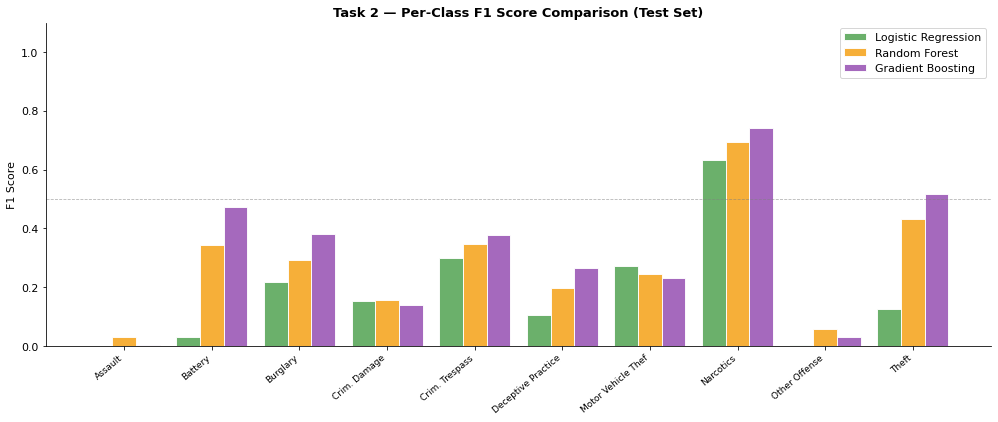

In [9]:
# ── Per-class F1 comparison — all Task 2 models ───────────────
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names))
w = 0.27
colors = ['#5ba85b', '#f5a623', '#9b59b6']

for i, (name, res) in enumerate(t2_results.items()):
    ax.bar(x + (i - 1) * w, res['f1_per_class'], w,
           label=name, color=colors[i], edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Task 2 — Per-Class F1 Score Comparison (Test Set)', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_task2_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print(f'\n  📋 Classification Report — {best_t2} (best on test)')
print(classification_report(
    y_te2, t2_results[best_t2]['y_pred'],
    target_names=class_names
))


  📋 Classification Report — Gradient Boosting (best on test)
                     precision    recall  f1-score   support

            ASSAULT       0.14      0.00      0.00      1191
            BATTERY       0.46      0.49      0.47      3573
           BURGLARY       0.32      0.48      0.38       942
    CRIMINAL DAMAGE       0.23      0.10      0.14      1934
  CRIMINAL TRESPASS       0.32      0.46      0.38       914
 DECEPTIVE PRACTICE       0.31      0.23      0.26       637
MOTOR VEHICLE THEFT       0.20      0.27      0.23       795
          NARCOTICS       0.66      0.84      0.74      3687
      OTHER OFFENSE       0.15      0.02      0.03       847
              THEFT       0.47      0.57      0.52      3480

           accuracy                           0.46     18000
          macro avg       0.33      0.35      0.32     18000
       weighted avg       0.41      0.46      0.42     18000



---
## 5. Task 3 — Crime Count: Full Test Evaluation

In [11]:
print('🔴 TASK 3 — Crime Count Regression — Test Set Results')
print('=' * 65)

# Models were trained on log1p — evaluate in original space
y_te3_log = np.log1p(y_te3)

t3_results = {}
for name, model in model_files['task3'].items():
    y_pred_log = model.predict(X_te3)
    y_pred     = np.expm1(y_pred_log)          # back to original scale
    y_pred     = np.clip(y_pred, 0, None)       # no negative counts

    rmse    = np.sqrt(mean_squared_error(y_te3, y_pred))
    mae     = mean_absolute_error(y_te3, y_pred)
    r2      = r2_score(y_te3, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_te3_log, y_pred_log))

    t3_results[name] = dict(rmse=rmse, mae=mae, r2=r2,
                             rmse_log=rmse_log,
                             y_pred=y_pred, y_pred_log=y_pred_log)
    print(f'  {name:<22} RMSE: {rmse:7.3f}  MAE: {mae:6.3f}  '
          f'R²: {r2:6.4f}  RMSE-log: {rmse_log:.4f}')

best_t3 = max(t3_results, key=lambda n: t3_results[n]['r2'])
print(f'\n  🏆 Best on test: {best_t3}')

🔴 TASK 3 — Crime Count Regression — Test Set Results
  Ridge Regression       RMSE:   1.280  MAE:  0.806  R²: 0.3679  RMSE-log: 0.3145
  Random Forest          RMSE:   1.161  MAE:  0.763  R²: 0.4797  RMSE-log: 0.3028
  Gradient Boosting      RMSE:   1.168  MAE:  0.763  R²: 0.4738  RMSE-log: 0.3010

  🏆 Best on test: Random Forest


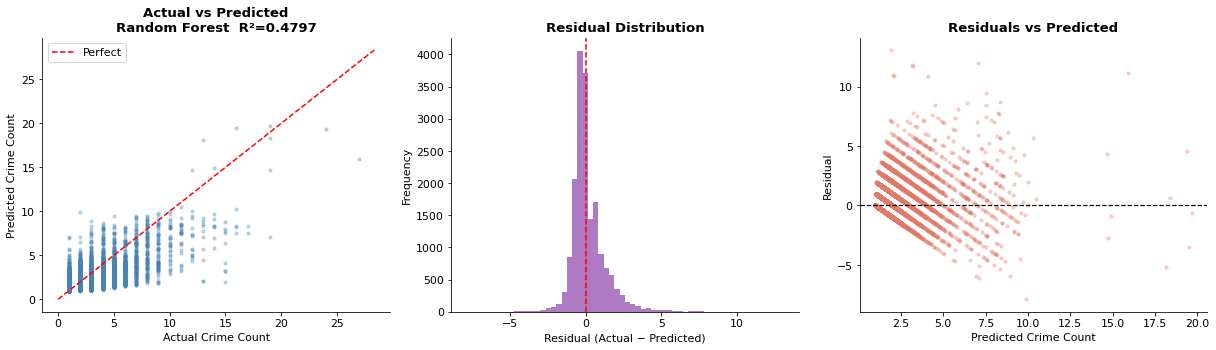

In [12]:
# ── Actual vs Predicted — best Task 3 model ──────────────────
y_pred_best = t3_results[best_t3]['y_pred']
residuals   = y_te3 - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter
lim = max(y_te3.max(), y_pred_best.max()) * 1.05
axes[0].scatter(y_te3, y_pred_best, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual Crime Count')
axes[0].set_ylabel('Predicted Crime Count')
axes[0].set_title(f'Actual vs Predicted\n{best_t3}  R²={t3_results[best_t3]["r2"]:.4f}',
                  fontweight='bold')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=60, color='#9b59b6', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

# Residuals vs Predicted
axes[2].scatter(y_pred_best, residuals, alpha=0.3, s=10, color='#e07b6a')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[2].set_xlabel('Predicted Crime Count')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_task3_regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

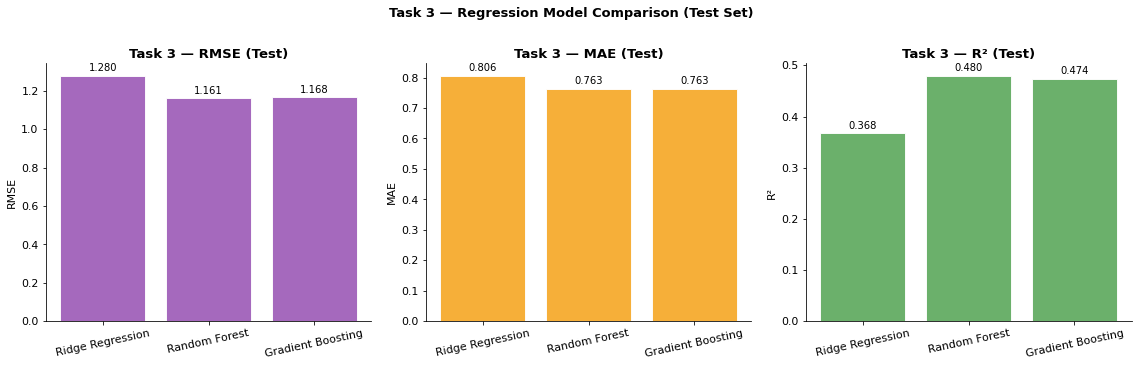

In [13]:
# ── All Task 3 models side-by-side ────────────────────────────
names_t3 = list(t3_results.keys())
metrics  = ['rmse', 'mae', 'r2']
labels   = ['RMSE', 'MAE', 'R²']
clrs     = ['#9b59b6', '#f5a623', '#5ba85b']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, label, color in zip(axes, metrics, labels, clrs):
    vals = [t3_results[n][metric] for n in names_t3]
    bars = ax.bar(names_t3, vals, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(f'Task 3 — {label} (Test)', fontweight='bold')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=12)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h * 0.02,
                f'{h:.3f}', ha='center', fontsize=10)

plt.suptitle('Task 3 — Regression Model Comparison (Test Set)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_task3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cross-Task Model Scorecard

In [14]:
# Build a unified scorecard DataFrame
rows = []

for name, res in t1_results.items():
    rows.append({
        'Task': 'Task 1 — Arrest', 'Model': name,
        'Primary Metric': f"AUC = {res['auc']:.4f}" if res['auc'] else f"F1 = {res['f1']:.4f}",
        'Secondary Metric': f"Acc = {res['acc']:.4f}",
        'Best': '🏆' if name == best_t1 else ''
    })

for name, res in t2_results.items():
    rows.append({
        'Task': 'Task 2 — Crime Type', 'Model': name,
        'Primary Metric': f"F1-w = {res['f1_w']:.4f}",
        'Secondary Metric': f"Acc = {res['acc']:.4f}",
        'Best': '🏆' if name == best_t2 else ''
    })

for name, res in t3_results.items():
    rows.append({
        'Task': 'Task 3 — Crime Count', 'Model': name,
        'Primary Metric': f"R² = {res['r2']:.4f}",
        'Secondary Metric': f"RMSE = {res['rmse']:.3f}",
        'Best': '🏆' if name == best_t3 else ''
    })

scorecard = pd.DataFrame(rows)
print(scorecard.to_string(index=False))

scorecard.to_csv(f'{DATA_DIR}/05_scorecard.csv', index=False)
print('\n✅ Scorecard saved → ml_data/05_scorecard.csv')

                 Task                Model Primary Metric Secondary Metric Best
      Task 1 — Arrest  Logistic Regression   AUC = 0.8519     Acc = 0.7681     
      Task 1 — Arrest        Random Forest   AUC = 0.8790     Acc = 0.7843     
      Task 1 — Arrest    Gradient Boosting   AUC = 0.8852     Acc = 0.7957    🏆
  Task 2 — Crime Type  Logistic Regression  F1-w = 0.2189     Acc = 0.2748     
  Task 2 — Crime Type        Random Forest  F1-w = 0.3652     Acc = 0.3893     
  Task 2 — Crime Type    Gradient Boosting  F1-w = 0.4217     Acc = 0.4614    🏆
 Task 3 — Crime Count     Ridge Regression    R² = 0.3679     RMSE = 1.280     
 Task 3 — Crime Count        Random Forest    R² = 0.4797     RMSE = 1.161    🏆
 Task 3 — Crime Count    Gradient Boosting    R² = 0.4738     RMSE = 1.168     

✅ Scorecard saved → ml_data/05_scorecard.csv


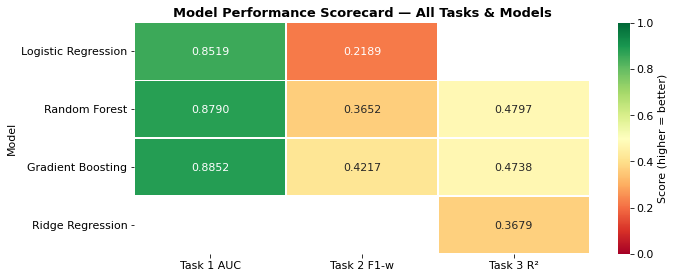

In [15]:
# ── Visual scorecard heatmap ──────────────────────────────────
score_matrix = pd.DataFrame({
    'Task 1 AUC'  : {n: t1_results[n]['auc'] or t1_results[n]['f1'] for n in t1_results},
    'Task 2 F1-w' : {n: t2_results[n]['f1_w'] for n in t2_results},
    'Task 3 R²'   : {n: t3_results[n]['r2'] for n in t3_results},
})

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(score_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Score (higher = better)'})
ax.set_title('Model Performance Scorecard — All Tasks & Models',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/05_scorecard_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Summary

In [16]:
print('=' * 70)
print('        NOTEBOOK 05 — EVALUATION & COMPARISON COMPLETE')
print('=' * 70)

print(f'\n  Task 1 — Arrest Prediction')
print(f'  Best model : {best_t1}')
print(f'  Test AUC   : {t1_results[best_t1]["auc"]:.4f}')
print(f'  Test F1    : {t1_results[best_t1]["f1"]:.4f}')
print(f'  Test Acc   : {t1_results[best_t1]["acc"]:.4f}')

print(f'\n  Task 2 — Crime Type Prediction')
print(f'  Best model     : {best_t2}')
print(f'  Test F1-weighted: {t2_results[best_t2]["f1_w"]:.4f}')
print(f'  Test F1-macro   : {t2_results[best_t2]["f1_macro"]:.4f}')
print(f'  Test Accuracy   : {t2_results[best_t2]["acc"]:.4f}')

print(f'\n  Task 3 — Crime Count Regression')
print(f'  Best model : {best_t3}')
print(f'  Test R²    : {t3_results[best_t3]["r2"]:.4f}')
print(f'  Test RMSE  : {t3_results[best_t3]["rmse"]:.3f}')
print(f'  Test MAE   : {t3_results[best_t3]["mae"]:.3f}')

print()
print('  📁 Outputs saved to ml_data/')
print('     05_task1_roc_pr.png')
print('     05_task1_confusion_matrices.png')
print('     05_task2_confusion_matrix.png')
print('     05_task2_per_class_f1.png')
print('     05_task3_regression_diagnostics.png')
print('     05_task3_model_comparison.png')
print('     05_scorecard.csv')
print('     05_scorecard_heatmap.png')
print()
print('    Next: 06_feature_importance_report.ipynb')
print('=' * 70)

        NOTEBOOK 05 — EVALUATION & COMPARISON COMPLETE

  Task 1 — Arrest Prediction
  Best model : Gradient Boosting
  Test AUC   : 0.8852
  Test F1    : 0.7918
  Test Acc   : 0.7957

  Task 2 — Crime Type Prediction
  Best model     : Gradient Boosting
  Test F1-weighted: 0.4217
  Test F1-macro   : 0.3165
  Test Accuracy   : 0.4614

  Task 3 — Crime Count Regression
  Best model : Random Forest
  Test R²    : 0.4797
  Test RMSE  : 1.161
  Test MAE   : 0.763

  📁 Outputs saved to ml_data/
     05_task1_roc_pr.png
     05_task1_confusion_matrices.png
     05_task2_confusion_matrix.png
     05_task2_per_class_f1.png
     05_task3_regression_diagnostics.png
     05_task3_model_comparison.png
     05_scorecard.csv
     05_scorecard_heatmap.png

    Next: 06_feature_importance_report.ipynb
